In [26]:
!git clone https://github.com/Ashaime2/FinanceProjects.git
%cd FinanceProjects

Cloning into 'FinanceProjects'...
remote: Enumerating objects: 62, done.
remote: Counting objects: 100% (62/62), done.
remote: Compressing objects: 100% (41/41), done.
remote: Total 62 (delta 17), reused 57 (delta 12), pack-reused 0 (from 0)
Receiving objects: 100% (62/62), 12.53 KiB | 3.13 MiB/s, done.
Resolving deltas: 100% (17/17), done.
/content/FinanceProjects/FinanceProjects/FinanceProjects


# Analyse élémentaire de stratégies d'options

Ce notebook utilise les fonctions déjà écrites dans `src/strategies.py`.

Objectifs :

1. construire plusieurs stratégies ;
2. calculer leur payoff terminal ;
3. calculer leur profit terminal en tenant compte du coût initial capitalisé ;
4. visualiser les résultats ;

Les premiums utilisés sont arbitraires.

## 1. Imports

In [27]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.strategies import (long_call,long_put,bull_call_spread,bear_put_spread,long_straddle,)

## 2. Paramètres communs

Le profit terminal est calculé par `profit_total` :

$$
\text{profit}(S_T)
=
\text{payoff}(S_T)
-
\text{coût initial}\,e^{rT}.
$$

In [28]:
rate = 0.03
maturity = 1.0

terminal_prices = np.linspace(50, 150, 201)

print(f"Taux continu : {rate:.1%}")
print(f"Maturité : {maturity} an")
print(f"Nombre de prix terminaux étudiés : {len(terminal_prices)}")

Taux continu : 3.0%
Maturité : 1.0 an
Nombre de prix terminaux étudiés : 201


## 3. Fonction d'analyse

In [29]:
def analyse_strategy(portfolio, terminal_prices, rate, maturity):
    payoffs = []
    profits = []

    for spot_price in terminal_prices:
        payoffs.append(portfolio.payoff_total(spot_price))
        profits.append(
            portfolio.profit_total(
                rate=rate,
                spot_price=spot_price,
                maturity=maturity,
            )
        )

    return np.array(payoffs), np.array(profits)

## 4. Visualisation des stratégies

In [30]:
def plot_strategy(
    terminal_prices,
    payoffs,
    profits,
    title,
    strikes,
):
    plt.figure(figsize=(9, 5))

    plt.plot(terminal_prices, payoffs, label="Payoff")
    plt.plot(terminal_prices, profits, label="Profit")

    plt.axhline(0, linewidth=1)

    for strike in strikes:
        plt.axvline(strike, linestyle="--", linewidth=1)

    plt.xlabel("Prix du sous-jacent à maturité $S_T$")
    plt.ylabel("Valeur")
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

# Partie A — Long call

Long Clal basique.

Coût initial : 8.0


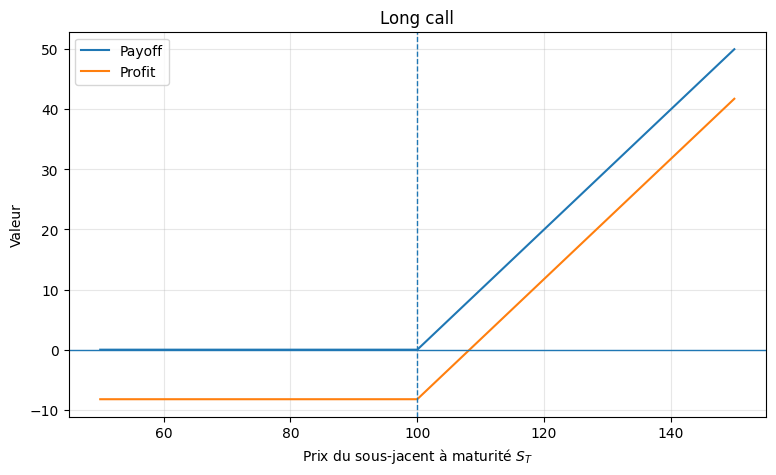

In [31]:
call_strike = 100
call_premium = 8

call_portfolio = long_call(
    strike=call_strike,
    premium=call_premium,
)

call_payoffs, call_profits = analyse_strategy(
    portfolio=call_portfolio,
    terminal_prices=terminal_prices,
    rate=rate,
    maturity=maturity,
)

print("Coût initial :", call_portfolio.initial_cost_total())

plot_strategy(
    terminal_prices=terminal_prices,
    payoffs=call_payoffs,
    profits=call_profits,
    title="Long call",
    strikes=[call_strike],
)

### Quelques tests manuels

In [32]:
for spot_price in [80, 100, 105, 110, 130]:
    payoff = call_portfolio.payoff_total(spot_price)
    profit = call_portfolio.profit_total(
        rate=rate,
        spot_price=spot_price,
        maturity=maturity,
    )

    print(
        f"S_T = {spot_price:>3} | "
        f"payoff = {payoff:>7.2f} | "
        f"profit = {profit:>7.2f}"
    )

S_T =  80 | payoff =    0.00 | profit =   -8.24
S_T = 100 | payoff =    0.00 | profit =   -8.24
S_T = 105 | payoff =    5.00 | profit =   -3.24
S_T = 110 | payoff =   10.00 | profit =    1.76
S_T = 130 | payoff =   30.00 | profit =   21.76


# Partie B — Long put

Long put simple

Coût initial : 7.0


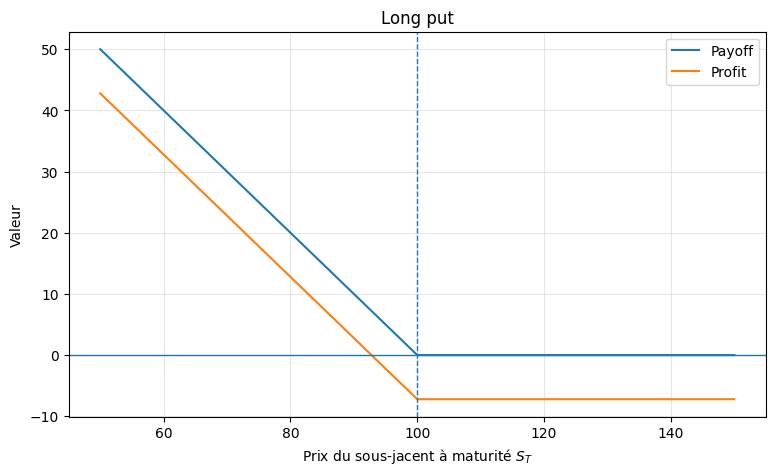

In [33]:
put_strike = 100
put_premium = 7

put_portfolio = long_put(
    strike=put_strike,
    premium=put_premium,
)

put_payoffs, put_profits = analyse_strategy(
    portfolio=put_portfolio,
    terminal_prices=terminal_prices,
    rate=rate,
    maturity=maturity,
)

print("Coût initial :", put_portfolio.initial_cost_total())

plot_strategy(
    terminal_prices=terminal_prices,
    payoffs=put_payoffs,
    profits=put_profits,
    title="Long put",
    strikes=[put_strike],
)

# Partie C — Bull call spread

## Construction

- achat d'un call au strike bas ;
- vente d'un call au strike haut.

On cherche un mouvement légèrement haussier. Le gain est plafonné de toute manière

Coût initial net : 10.0


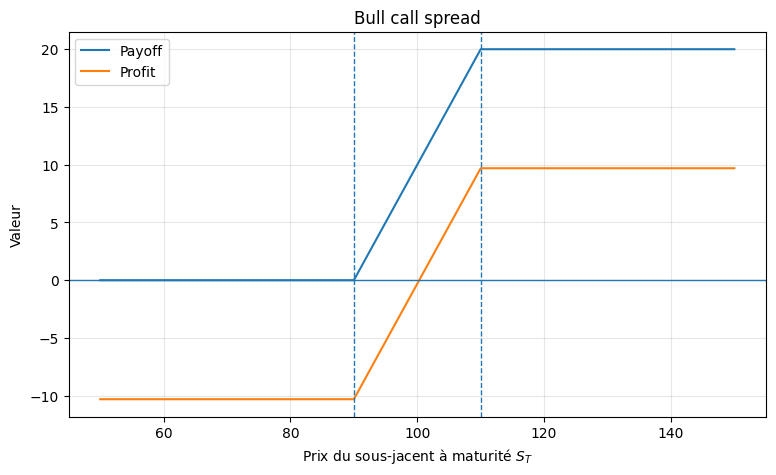

In [34]:
bull_lower_strike = 90
bull_upper_strike = 110
bull_lower_premium = 14
bull_upper_premium = 4

bull_portfolio = bull_call_spread(
    lower_strike=bull_lower_strike,
    lower_premium=bull_lower_premium,
    upper_strike=bull_upper_strike,
    upper_premium=bull_upper_premium,
)

bull_payoffs, bull_profits = analyse_strategy(
    portfolio=bull_portfolio,
    terminal_prices=terminal_prices,
    rate=rate,
    maturity=maturity,
)

print("Coût initial net :", bull_portfolio.initial_cost_total())

plot_strategy(
    terminal_prices=terminal_prices,
    payoffs=bull_payoffs,
    profits=bull_profits,
    title="Bull call spread",
    strikes=[bull_lower_strike, bull_upper_strike],
)

# Partie D — Bear put spread

## Construction

- achat d'un put au strike haut ;
- vente d'un put au strike bas.

On cherche un mouvement légèrement baissier.

Coût initial net : 10.0


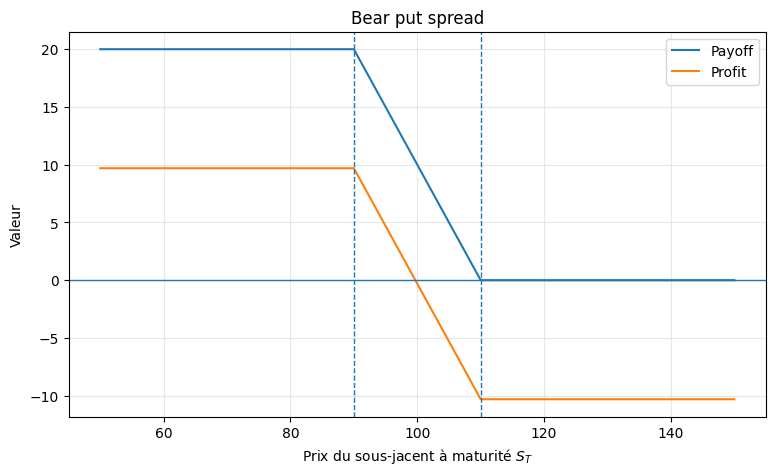

In [35]:
bear_lower_strike = 90
bear_upper_strike = 110
bear_lower_premium = 3
bear_upper_premium = 13

bear_portfolio = bear_put_spread(
    lower_strike=bear_lower_strike,
    lower_premium=bear_lower_premium,
    upper_strike=bear_upper_strike,
    upper_premium=bear_upper_premium,
)

bear_payoffs, bear_profits = analyse_strategy(
    portfolio=bear_portfolio,
    terminal_prices=terminal_prices,
    rate=rate,
    maturity=maturity,
)

print("Coût initial net :", bear_portfolio.initial_cost_total())

plot_strategy(
    terminal_prices=terminal_prices,
    payoffs=bear_payoffs,
    profits=bear_profits,
    title="Bear put spread",
    strikes=[bear_lower_strike, bear_upper_strike],
)

# Partie E — Long straddle

## Construction

- achat d'un call ;
- achat d'un put ;
- même strike.

On cherche un gros mouvement, peu importe la direction.

Coût initial : 15.0


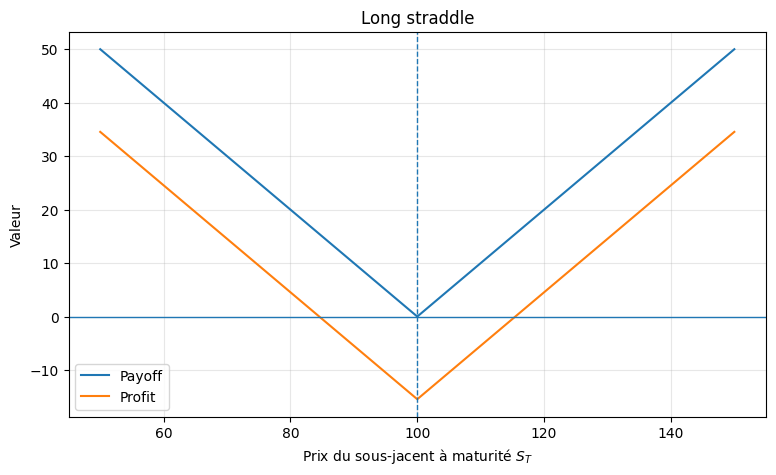

In [36]:
straddle_strike = 100
straddle_call_premium = 8
straddle_put_premium = 7

straddle_portfolio = long_straddle(
    strike=straddle_strike,
    call_premium=straddle_call_premium,
    put_premium=straddle_put_premium,
)

straddle_payoffs, straddle_profits = analyse_strategy(
    portfolio=straddle_portfolio,
    terminal_prices=terminal_prices,
    rate=rate,
    maturity=maturity,
)

print("Coût initial :", straddle_portfolio.initial_cost_total())

plot_strategy(
    terminal_prices=terminal_prices,
    payoffs=straddle_payoffs,
    profits=straddle_profits,
    title="Long straddle",
    strikes=[straddle_strike],
)

# 5. Comparaison des profits

Graphique synthétique des profits par stratégie

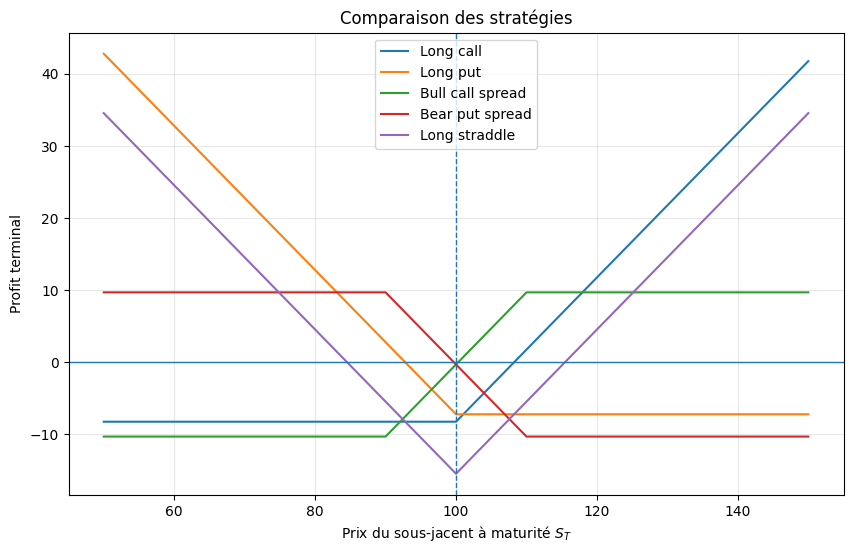

In [37]:
plt.figure(figsize=(10, 6))

plt.plot(terminal_prices, call_profits, label="Long call")
plt.plot(terminal_prices, put_profits, label="Long put")
plt.plot(terminal_prices, bull_profits, label="Bull call spread")
plt.plot(terminal_prices, bear_profits, label="Bear put spread")
plt.plot(terminal_prices, straddle_profits, label="Long straddle")

plt.axhline(0, linewidth=1)
plt.axvline(100, linestyle="--", linewidth=1)

plt.xlabel("Prix du sous-jacent à maturité $S_T$")
plt.ylabel("Profit terminal")
plt.title("Comparaison des stratégies")
plt.legend()
plt.grid(alpha=0.3)
plt.show()